<a href="https://colab.research.google.com/github/safosaffers/4C_8S_AdMap_VN/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

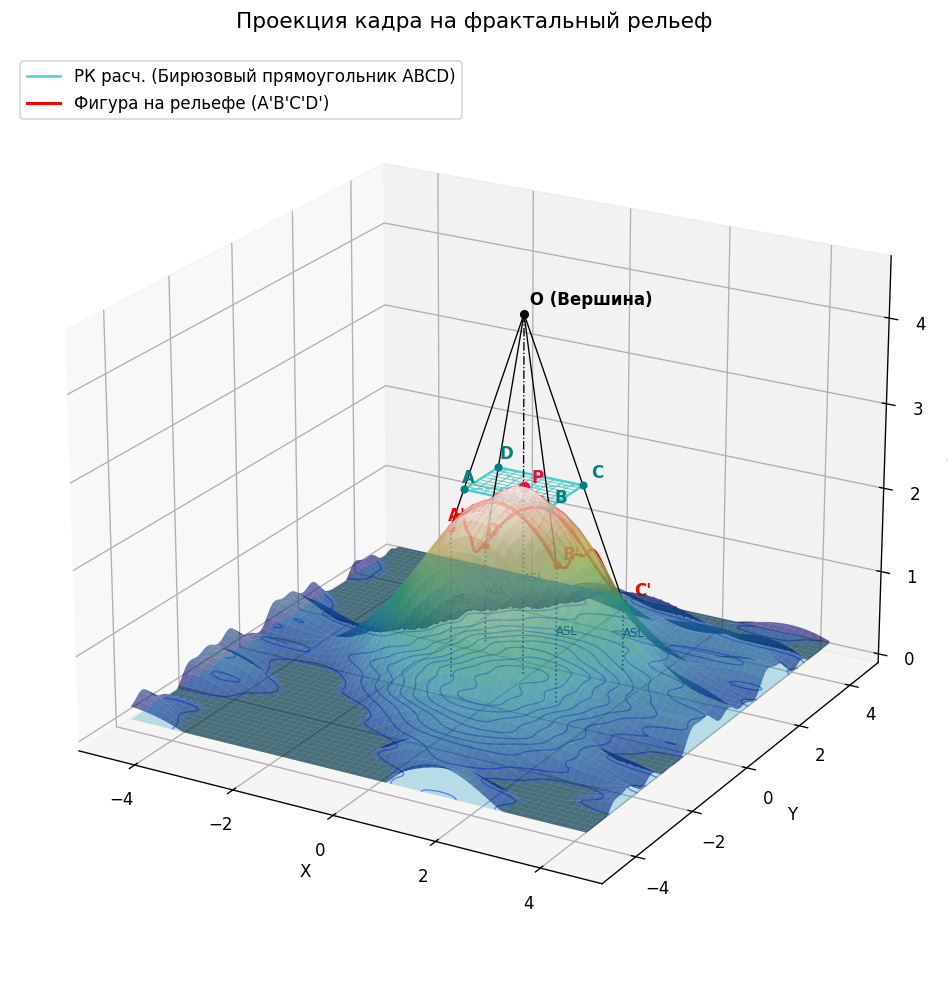

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import RegularGridInterpolator

# Настройка фигуры Matplotlib
fig = plt.figure(figsize=(12, 10), dpi=120)
ax = fig.add_subplot(111, projection='3d')

# -----------------------------------------------------------------------------
# 1. СЕТКА И КОРДИНАТНОЕ ПРОСТРАНСТВО
# -----------------------------------------------------------------------------
grid_size = 120
x_min, x_max = -4.5, 4.5
y_min, y_max = -4.5, 4.5

x = np.linspace(x_min, x_max, grid_size)
y = np.linspace(y_min, y_max, grid_size)
X, Y = np.meshgrid(x, y)

# -----------------------------------------------------------------------------
# 2. ГЕНЕРАЦИЯ ФРАКТАЛЬНОГО РЕЛЬЕФА (ХОЛМА)
# -----------------------------------------------------------------------------
np.random.seed(101)

def fractal_hill_generator(X, Y, octaves=5):
    base_height = 2.4
    base_spread = 6.0
    R2 = X**2 + Y**2
    Z_base = base_height * np.exp(-R2 / base_spread)

    Z_noise = np.zeros_like(X)
    for i in range(octaves):
        freq = 0.7 * (1.9**i)
        amp = 0.35 / (1.8**i)
        angle = np.random.uniform(0, 2*np.pi)
        phase = np.random.uniform(0, 2*np.pi)

        kx = freq * np.cos(angle)
        ky = freq * np.sin(angle)
        Z_noise += amp * np.sin(kx * X + ky * Y + phase)

    Z = Z_base + Z_noise
    return Z

Z_terrain = fractal_hill_generator(X, Y)
z_water = 0.2
Z_terrain_water = np.maximum(Z_terrain, z_water)

# -----------------------------------------------------------------------------
# 3. ПОИСК ПИКА (САМОЙ ВЫСОКОЙ ТОЧКИ ХОЛМА)
# -----------------------------------------------------------------------------
max_idx = np.unravel_index(np.argmax(Z_terrain_water), Z_terrain_water.shape)
x_peak = float(X[max_idx])
y_peak = float(Y[max_idx])
z_peak = float(Z_terrain_water[max_idx])

# -----------------------------------------------------------------------------
# 4. ТРАССИРОВКА ЛУЧЕЙ (ПЕРЕСЕЧЕНИЕ С РЕЛЬЕФОМ)
# -----------------------------------------------------------------------------
interp_Z = RegularGridInterpolator((y, x), Z_terrain_water)

def intersect_ray(O, V):
    direction = V - O
    t_vals = np.linspace(1.0, 3.5, 600)
    pts = O + t_vals[:, None] * direction

    valid = (pts[:, 0] >= x.min()) & (pts[:, 0] <= x.max()) & \
            (pts[:, 1] >= y.min()) & (pts[:, 1] <= y.max())
    pts_valid = pts[valid]

    z_terrain = interp_Z((pts_valid[:, 1], pts_valid[:, 0]))
    diff = pts_valid[:, 2] - z_terrain
    idx = np.argmin(np.abs(diff))
    return pts_valid[idx]

# -----------------------------------------------------------------------------
# 5. ГЕОМЕТРИЧЕСКИЕ ПАРАМЕТРЫ ПИРАМИДЫ И КАДРОВ
# -----------------------------------------------------------------------------
h_apex = 2.0
O = np.array([x_peak, y_peak, z_peak + h_apex])

P = np.array([x_peak, y_peak, z_peak])
z_flat = z_peak

w = 0.85
h_frame = 0.60

A = np.array([x_peak - w, y_peak - h_frame, z_flat])
B = np.array([x_peak + w, y_peak - h_frame, z_flat])
C = np.array([x_peak + w, y_peak + h_frame, z_flat])
D = np.array([x_peak - w, y_peak + h_frame, z_flat])

A_p = intersect_ray(O, A)
B_p = intersect_ray(O, B)
C_p = intersect_ray(O, C)
D_p = intersect_ray(O, D)
P_p = intersect_ray(O, P)

def project_boundary(O, pts, samples_per_edge=40):
    boundary = []
    for i in range(len(pts)):
        p_start = pts[i]
        p_end = pts[(i+1)%len(pts)]
        for t in np.linspace(0, 1, samples_per_edge, endpoint=False):
            p_curr = p_start + t * (p_end - p_start)
            boundary.append(intersect_ray(O, p_curr))
    boundary.append(boundary[0])
    return np.array(boundary)

red_boundary = project_boundary(O, [A, B, C, D])

# -----------------------------------------------------------------------------
# 6. ОТРИСОВКА 3D-СЦЕНЫ
# -----------------------------------------------------------------------------
# Поверхность рельефа
surf = ax.plot_surface(X, Y, Z_terrain_water, cmap='gist_earth', alpha=0.6, edgecolor='none', rstride=2, cstride=2)

# Вода и горизонтали
X_w, Y_w = np.meshgrid(np.linspace(x_min, x_max, 20), np.linspace(y_min, y_max, 20))
Z_w = np.full_like(X_w, z_water)
ax.plot_surface(X_w, Y_w, Z_w, color='deepskyblue', alpha=0.25)
ax.contour(X, Y, Z_terrain_water, levels=8, zdir='z', offset=z_water, colors='blue', linewidths=0.8, alpha=0.5)

# -----------------------------------------------------------------------------
# ШТРИХОВАЯ СЕТКА ВНУТРИ КАДРОВ
# -----------------------------------------------------------------------------
n_hatch = 10  # Число линий сетки по каждой оси
u_grid = np.linspace(-w, w, n_hatch)
v_grid = np.linspace(-h_frame, h_frame, n_hatch)

# 1. Бирюзовая сетка на плоском кадре
for u in u_grid:
    p1 = np.array([x_peak + u, y_peak - h_frame, z_flat])
    p2 = np.array([x_peak + u, y_peak + h_frame, z_flat])
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color='lightseagreen', lw=0.6, alpha=0.6)

for v in v_grid:
    p1 = np.array([x_peak - w, y_peak + v, z_flat])
    p2 = np.array([x_peak + w, y_peak + v, z_flat])
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color='lightseagreen', lw=0.6, alpha=0.6)

# 2. Красная сетка на рельефе (проецирование линий)
for u in u_grid:
    p1 = np.array([x_peak + u, y_peak - h_frame, z_flat])
    p2 = np.array([x_peak + u, y_peak + h_frame, z_flat])
    line_pts = np.array([intersect_ray(O, p1 + t * (p2 - p1)) for t in np.linspace(0, 1, 20)])
    ax.plot(line_pts[:,0], line_pts[:,1], line_pts[:,2], color='red', lw=0.6, alpha=0.6)

for v in v_grid:
    p1 = np.array([x_peak - w, y_peak + v, z_flat])
    p2 = np.array([x_peak + w, y_peak + v, z_flat])
    line_pts = np.array([intersect_ray(O, p1 + t * (p2 - p1)) for t in np.linspace(0, 1, 20)])
    ax.plot(line_pts[:,0], line_pts[:,1], line_pts[:,2], color='red', lw=0.6, alpha=0.6)

# -----------------------------------------------------------------------------
# ОСНОВНЫЕ КОНТУРЫ И ЭЛЕМЕНТЫ
# -----------------------------------------------------------------------------
# Прямоугольник ABCD
rect_x = [A[0], B[0], C[0], D[0], A[0]]
rect_y = [A[1], B[1], C[1], D[1], A[1]]
rect_z = [A[2], B[2], C[2], D[2], A[2]]
ax.plot(rect_x, rect_y, rect_z, color='mediumturquoise', lw=1.5, label='Размеры кадра расчётные (прямоугольник ABCD)')

# Диагонали
ax.plot([A[0], C[0]], [A[1], C[1]], [A[2], C[2]], color='mediumturquoise', lw=0.8, ls='--')
ax.plot([B[0], D[0]], [B[1], D[1]], [B[2], D[2]], color='mediumturquoise', lw=0.8, ls='--')

# Красная фигура A'B'C'D'
ax.plot(red_boundary[:,0], red_boundary[:,1], red_boundary[:,2], color='red', lw=1.8, label="Фигура на рельефе (A'B'C'D')")

# Грани пирамиды
for V_p in [A_p, B_p, C_p, D_p]:
    ax.plot([O[0], V_p[0]], [O[1], V_p[1]], [O[2], V_p[2]], color='black', lw=0.8, ls='-')

# Центральная ось O -> P
ax.plot([O[0], P_p[0]], [O[1], P_p[1]], [O[2], P_p[2]], color='black', lw=0.8, ls='-.')

# Точки
ax.scatter(*O, color='black', s=20)
ax.scatter(*P, color='crimson', s=35, zorder=10)

for pt, lbl in zip([A, B, C, D], ['A', 'B', 'C', 'D']):
    ax.scatter(*pt, color='teal', s=15)
    ax.text(pt[0]*1.08, pt[1]*1.08, pt[2]+0.08, lbl, color='teal', fontsize=10, fontweight='bold')

for pt, lbl in zip([A_p, B_p, C_p, D_p], ["A'", "B'", "C'", "D'"]):
    ax.scatter(*pt, color='red', s=15)
    ax.text(pt[0]*1.08, pt[1]*1.08, pt[2]+0.08, lbl, color='red', fontsize=10, fontweight='bold')

ax.text(O[0], O[1], O[2]+0.1, ' O (Вершина)', color='black', fontsize=10, fontweight='bold')
ax.text(P[0]+0.1, P[1]+0.1, P[2]+0.05, "P", color='crimson', fontsize=10, fontweight='bold')

# Линии высот ASL
for pt in [A_p, B_p, C_p, D_p, P_p]:
    ax.plot([pt[0], pt[0]], [pt[1], pt[1]], [z_water, pt[2]], color='navy', ls=':', lw=1.0)
    z_mid = (z_water + pt[2]) / 2.0
    ax.text(pt[0], pt[1], z_mid, "ASL", color='navy', fontsize=7)

# Настройка оси и сетки
ax.grid(True)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Вид со стороны
ax.view_init(elev=22, azim=-60)
# Вид строго сверху (надир)
# ax.view_init(elev=90, azim=-90)
ax.set_title("Проекция кадра на фрактальный рельеф", fontsize=13, pad=15)
ax.legend(loc='upper left')

plt.savefig("fractal_projection_scene.png", bbox_inches='tight', dpi=150)
plt.show()